# Workshop 1 — Machine Learning
### Análisis Exploratorio de Datos (EDA) — Anime Recommendations Database

Este notebook desarrolla el ciclo completo de EDA (reconocimiento, limpieza, análisis descriptivo y visualización) sobre el dataset de Kaggle **Anime Recommendations Database**, que trae la info de 12,294 animes listados en MyAnimeList (nombre, género, tipo, episodios, rating y cantidad de miembros que lo siguen).

## Fase 1 — Reconocimiento inicial

El dataset que nos tocó es sobre animes: básicamente tiene el catálogo completo de MyAnimeList con info de cada uno (género, tipo, cuántos episodios tiene, qué tan bien calificado está y cuánta gente lo sigue). La idea es entender qué hace que un anime sea popular o bien calificado, que puede servir después para un modelo que prediga esto.

**Lo que dice la documentación oficial de Kaggle.** El dataset recoge las preferencias de **73,516 usuarios** sobre **12,294 animes**: cada usuario puede agregar animes a su lista de "completados" y ponerles una calificación, y el dataset es la recopilación de todas esas calificaciones. Viene repartido en **dos archivos**:

- **`anime.csv`** → 12,294 filas, un registro **por anime** (el catálogo, con sus atributos y su calificación promedio).
- **`rating.csv`** → ~7.8 millones de filas, un registro **por calificación de un usuario** (`user_id` anonimizado, `anime_id`, y `rating` sobre 10, con **`-1` cuando el usuario vio el anime pero no lo calificó**).

Nosotros trabajamos con **`anime.csv`**, porque el workshop pide explorar y describir un dataset y este es el que tiene las variables descriptivas del catálogo (género, tipo, episodios, rating promedio, members). `rating.csv` es de interacciones usuario-ítem: sirve para construir un sistema de recomendación, no para el EDA descriptivo que nos piden acá, y con 7.8 millones de filas se sale del alcance del taller. Lo dejamos anotado como trabajo futuro.

**Diccionario de datos** (la descripción es la de la documentación oficial, no una interpretación nuestra):

| Columna | Tipo esperado | Qué significa según la documentación |
|---|---|---|
| anime_id | numérico (int) | ID único que identifica al anime en **myanimelist.net** |
| name | texto | Nombre completo del anime |
| genre | texto (lista separada por comas) | Lista de géneros del anime, separados por coma |
| type | categórica | Formato del anime: Movie, TV, OVA, Special, ONA o Music |
| episodes | numérico (int) | Cuántos episodios tiene el show (**1 si es película**) |
| rating | numérico (float) | Calificación promedio **sobre 10** que recibió este anime |
| members | numérico (int) | Número de miembros de la comunidad que están en el **"grupo" de ese anime** |

Dos aclaraciones que nos parecieron importantes antes de arrancar:

- **`members` no es "cuánta gente lo vio"**, sino cuánta gente pertenece al grupo del anime en MyAnimeList. No es exactamente lo mismo, pero es lo más cercano que tenemos a una medida de popularidad, y así la usamos en todo el análisis.
- **`rating` es un promedio, y el dataset no dice de cuántos votos sale.** Eso significa que un anime con 10.0 no necesariamente es mejor que uno con 8.5: puede ser que lo hayan calificado dos personas. Esta limitación nos persigue hasta las conclusiones.

Con el `.shape` vemos que son 12,294 filas y 7 columnas, tal como dice la documentación.

In [1]:
# Bloque 1: Importar librerías y cargar el dataset
import os
import html

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# El dataset se baja de Kaggle con kagglehub (funciona igual en Colab y en local).
# Si el CSV ya está al lado del notebook lo usa y no vuelve a descargar nada.
ARCHIVO = 'anime.csv'

if os.path.exists(ARCHIVO):
    ruta_csv = ARCHIVO
    print("Usando el archivo local:", ruta_csv)
else:
    try:
        import kagglehub

        path = kagglehub.dataset_download("CooperUnion/anime-recommendations-database")
        print("Path to dataset files:", path)
        ruta_csv = os.path.join(path, ARCHIVO)
    except Exception as e:
        # Último recurso: subir el archivo a mano (solo funciona en Colab)
        print("No se pudo usar kagglehub:", e)
        from google.colab import files

        files.upload()
        ruta_csv = ARCHIVO

df = pd.read_csv(ruta_csv)
print(df.shape)
df.head()

Usando el archivo local: anime.csv
(12294, 7)


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [2]:
# Primeras y últimas 5 filas
print(df.head())
print(df.tail())

print("Filas y columnas:", df.shape)

   anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   
2     28977                          Gintama°   
3      9253                       Steins;Gate   
4      9969                     Gintama&#039;   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   
2  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.25   
3                                   Sci-Fi, Thriller     TV       24    9.17   
4  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.16   

   members  
0   200630  
1   793665  
2   114262  
3   673572  
4   151266  
       anime_id                                               name   genre  \
12289      9316       Toushindai My Lover: Minami tai Mecha-Minami  

In [3]:
df.info()
print("\nTipos de datos:\n", df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  str    
 2   genre     12232 non-null  str    
 3   type      12269 non-null  str    
 4   episodes  12294 non-null  str    
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 672.5 KB

Tipos de datos:
 anime_id      int64
name            str
genre           str
type            str
episodes        str
rating      float64
members       int64
dtype: object


Con `.info()` y `.dtypes` clasificamos las columnas:

- **Numéricas:** `rating` (float64), `members` (int64) y `anime_id` (int64, aunque este último es un identificador, no una medida: no tiene sentido sacarle promedio). `episodes` *debería* ser numérica, pero pandas la leyó como **texto** (aparece como `str`, o como `object` en versiones anteriores de pandas) — esa es la primera señal de que algo raro trae adentro, y lo revisamos en la Fase 2.
- **Categóricas / texto:** `type` (categórica de verdad, 6 valores posibles), `genre` (texto multi-valor: varios géneros separados por coma en la misma celda) y `name` (texto libre, prácticamente un identificador).
- **De fecha:** **ninguna.** El dataset no trae año de estreno, temporada ni fecha de emisión. Lo dejamos anotado desde ya porque tiene una consecuencia directa en el punto 21: sin variable temporal no se puede hacer un gráfico de líneas en el tiempo.

Otra cosa que se ve en el `.info()`: `genre` (12,232), `type` (12,269) y `rating` (12,064) reportan menos valores no-nulos que las 12,294 filas, o sea que ahí hay nulos que toca tratar.

In [4]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


Mirando el `.describe()`, hay tres cosas que nos parecieron importantes:

- El `rating` promedio es de 6.47 con una desviación de apenas 1.03, o sea que la mayoría de los animes se mueven en un rango bastante cerrado (como entre 5.4 y 7.5). El mínimo es 1.67, así que tampoco hay animes con calificación horrible.
- En `members` la cosa cambia total: la media es 18,071 pero la desviación estándar es 54,818, o sea casi 3 veces más grande que la media. Eso ya nos dice que la variable está bien sesgada, seguramente por unos pocos animes súper populares que se salen del montón (esto lo confirmamos más adelante con el IQR).
- Varias columnas tienen menos de 12,294 en el conteo (`genre`, `type`, `rating`), lo que quiere decir que ahí hay nulos que toca revisar en la limpieza.

In [5]:
# Usamos 'members' como ejemplo (rating también podría servir, pero members no tiene nulos)
members_array = df['members'].to_numpy()

print("Media (NumPy):", np.mean(members_array))
print("Mediana (NumPy):", np.median(members_array))
print("Desv. estándar (NumPy):", np.std(members_array))

Media (NumPy): 18071.33886448674
Mediana (NumPy): 1550.0
Desv. estándar (NumPy): 54818.447309169394


Calculamos a mano con NumPy la media, la mediana y la desviación de `members`, y da prácticamente lo mismo que con pandas. La mediana (1,550) es muchísimo más baja que la media (18,071), lo que refuerza lo que decíamos arriba: hay pocos animes con demasiados members que "jalan" el promedio para arriba.

Un detalle que notamos comparando con el `.describe()`: `np.std()` nos dio **54,818.45** y pandas reporta **54,820.68**. No es un error — `np.std()` calcula por defecto la desviación **poblacional** (divide entre *n*) y `pandas.std()` la **muestral** (divide entre *n-1*). Con 12,294 filas la diferencia es mínima, pero vale la pena saber por qué pasa.

## Fase 2 — Limpieza de datos

In [6]:
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

resumen_nulos = pd.DataFrame({'nulos': nulos, 'porcentaje_%': porcentaje_nulos.round(2)})
print(resumen_nulos[resumen_nulos['nulos'] > 0])

        nulos  porcentaje_%
genre      62          0.50
type       25          0.20
rating    230          1.87


In [7]:
# "Unknown" -> NaN, y luego convertir a numérico
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')

# ¿Cuántos "Unknown" (ahora NaN) había?
print("Nulos en episodes tras conversión:", df['episodes'].isnull().sum())
df['episodes'].describe()

Nulos en episodes tras conversión: 340


count    11954.000000
mean        12.382550
std         46.865352
min          1.000000
25%          1.000000
50%          2.000000
75%         12.000000
max       1818.000000
Name: episodes, dtype: float64

Encontramos nulos en `genre` (62, 0.5%), `type` (25, 0.2%) y `rating` (230, 1.87%). Además, `episodes` venía como texto porque tenía la palabra "Unknown" en vez de un número — al convertirlo a numérico, esos "Unknown" se volvieron 340 nulos (2.77%).

Con esto decidimos qué hacer con cada uno:

- **genre**: como son pocos nulos (0.5%), los rellenamos con la palabra "Unknown" en vez de borrar la fila, para no perder el resto de info de esos animes (rating, members, etc).
- **episodes**: lo rellenamos con la **mediana** (no la media) porque esta columna tiene outliers extremos (hay animes con más de 1800 episodios), entonces la media queda inflada y no representa bien al "anime típico".
- **type** y **rating**: estos sí los eliminamos. No tiene sentido inventarnos de qué tipo es un anime o qué rating tiene — sería literalmente inventar el dato. Como son pocas filas (menos del 2%), no afecta el análisis.

In [8]:
# 1. genre -> imputar "Unknown"
df['genre'] = df['genre'].fillna('Unknown')

# 2. episodes -> imputar con mediana
mediana_episodes = df['episodes'].median()
df['episodes'] = df['episodes'].fillna(mediana_episodes)
print("Mediana usada para episodes:", mediana_episodes)

# 3. type y rating -> eliminar filas (no tiene sentido inventar el valor)
filas_antes = df.shape[0]
df = df.dropna(subset=['type', 'rating'])
filas_despues = df.shape[0]
print(f"Filas eliminadas por nulos en type/rating: {filas_antes - filas_despues}")

# Verificación final
print("\nNulos restantes:\n", df.isnull().sum())
print("Shape final:", df.shape)

Mediana usada para episodes: 2.0
Filas eliminadas por nulos en type/rating: 230

Nulos restantes:
 anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64
Shape final: (12064, 7)


Al final quedamos con 12,064 filas y cero nulos. Ojo con un detalle: eliminamos 230 filas en total, no 255 (que sería 230+25), lo que nos dice que los 25 registros sin `type` probablemente ya estaban incluidos dentro de los 230 que tampoco tenían `rating`.

In [9]:
# Ahora que 'episodes' ya es numérica, el describe() cubre las 4 columnas numéricas reales
df.describe()

,anime_id,episodes,rating,members
count,12064.000000,12064.000000,12064.000000,1.206400e+04
mean,13704.476044,12.284483,6.473902,1.827952e+04
std,11260.369521,46.661240,1.026746,5.527578e+04
min,1.000000,1.000000,1.670000,1.200000e+01
25%,3409.250000,1.000000,5.880000,2.210000e+02
50%,10004.000000,2.000000,6.570000,1.539000e+03
75%,23863.500000,12.000000,7.180000,9.485500e+03
max,34519.000000,1818.000000,10.000000,1.013917e+06


Este segundo `.describe()` es el que completa el punto 5: el de la Fase 1 no podía mostrar `episodes` porque en ese momento la columna todavía era texto (por los "Unknown"), así que solo salían 3 columnas. Ahora sí tenemos las 4 numéricas.

Lo interesante está en **`episodes`**:

- La **mediana es 2** pero la **media es 12.28**, seis veces más grande. Es el mismo patrón que ya vimos con `members`: unas pocas series larguísimas jalan el promedio hacia arriba. De hecho el percentil 25 y el 50 valen 1 y 2 episodios — más de la mitad del catálogo (6,875 títulos) son cosas de uno o dos capítulos: películas, OVAs, especiales y videos musicales.
- El **máximo es 1,818 episodios** (*Oyako Club*), con una desviación estándar de 46.66. Ese solo dato explica por qué en el punto 8 imputamos con **mediana y no con media**: si hubiéramos usado la media, a los 340 animes con episodios desconocidos les habríamos puesto 12 capítulos a cada uno, cuando el anime típico tiene 2.
- Solo 159 animes (1.3%) pasan de 100 episodios, o sea que las series largas tipo One Piece son la excepción y no la regla.

Un detalle de lectura: `anime_id` sale en la tabla porque es numérica, pero sus estadísticos no significan nada — es un identificador, no una medida. Que su media sea 13,704 no dice absolutamente nada sobre el catálogo.

In [10]:
# a) Filas completamente duplicadas
duplicados = df.duplicated().sum()
print("Filas duplicadas (fila completa):", duplicados)

filas_antes = df.shape[0]
df = df.drop_duplicates()
print("Filas eliminadas por duplicado:", filas_antes - df.shape[0])
print("Shape después de eliminar duplicados:", df.shape)

# b) Vamos más allá: revisamos duplicados en el identificador y en el nombre
print("\nIDs repetidos (anime_id):", df['anime_id'].duplicated().sum())
print("Nombres repetidos (name):", df['name'].duplicated().sum())

repetidos = df[df['name'].duplicated(keep=False)].sort_values('name')
print("\nRegistros que comparten nombre:")
print(repetidos[['anime_id', 'name', 'type', 'episodes', 'rating', 'members']].to_string(index=False))

Filas duplicadas (fila completa): 0
Filas eliminadas por duplicado: 0
Shape después de eliminar duplicados: (12064, 7)

IDs repetidos (anime_id): 0
Nombres repetidos (name): 2

Registros que comparten nombre:
 anime_id                    name  type  episodes  rating  members
    22399        Saru Kani Gassen   OVA       1.0    5.23       62
    30059        Saru Kani Gassen Movie       1.0    4.75       76
    33193 Shi Wan Ge Leng Xiaohua   ONA      12.0    6.67      114
    33195 Shi Wan Ge Leng Xiaohua Movie       1.0    7.07      110


No hay ninguna fila **completamente** duplicada (0), así que por ese lado no se eliminó nada.

Pero no nos quedamos ahí y revisamos duplicados columna por columna: `anime_id` no tiene ni uno repetido (funciona bien como identificador único, como esperábamos), y en `name` aparecen **2 nombres repetidos**: *Saru Kani Gassen* y *Shi Wan Ge Leng Xiaohua*.

Los miramos de cerca y **decidimos no eliminarlos**, porque no son duplicados de verdad: cada par tiene distinto `anime_id`, distinto `type` (uno es OVA y el otro Movie, o uno ONA y el otro Movie), distinto número de episodios y distinto rating. Son dos adaptaciones diferentes de la misma historia, no un error de carga. Borrar una de las dos sería perder información real del catálogo.

In [11]:
# --- 1) 'type': ¿mayúsculas/minúsculas o espacios inconsistentes? ---
print("Valores únicos en 'type':", df['type'].unique())
print("Con repr() para ver espacios ocultos:", [repr(t) for t in df['type'].unique()])
print("Filas de 'type' que cambian al aplicar .strip():", (df['type'] != df['type'].str.strip()).sum())

# --- 2) 'name': buscamos entidades HTML (&quot;, &#039;, &amp;) ---
patron_html = r'&[a-zA-Z]+;|&#[0-9]+;'
con_entidades = df['name'].str.contains(patron_html, regex=True, na=False)
print("\nNombres con entidades HTML:", con_entidades.sum(),
      f"({con_entidades.sum() / len(df) * 100:.2f}% del catálogo)")
print("\nEjemplos ANTES de corregir:")
print(df.loc[con_entidades, 'name'].head(5).to_string(index=False))

df['name'] = df['name'].apply(html.unescape).str.strip()

print("\nEjemplos DESPUÉS de corregir:")
print(df.loc[con_entidades, 'name'].head(5).to_string(index=False))
print("\nNombres que todavía tienen entidades:",
      df['name'].str.contains(patron_html, regex=True, na=False).sum())

# --- 3) 'genre': es multi-valor, hay que revisar los géneros individuales ---
generos_crudos = df['genre'].str.split(',').explode()          # partimos SOLO por la coma
print("\nGéneros distintos SIN limpiar:", generos_crudos.nunique())
print("Tokens con espacios sobrantes:", (generos_crudos != generos_crudos.str.strip()).sum())

generos_limpios = generos_crudos.str.strip()
print("Géneros distintos DESPUÉS de .strip():", generos_limpios.nunique())
print("Géneros distintos ignorando mayúsculas/minúsculas:", generos_limpios.str.lower().nunique())

# Normalizamos la columna para dejarla siempre como 'Genero1, Genero2, ...'
genre_antes = df['genre'].copy()
df['genre'] = df['genre'].apply(lambda s: ', '.join(g.strip() for g in s.split(',')))
print("Filas de 'genre' modificadas al normalizar:", (genre_antes != df['genre']).sum())

Valores únicos en 'type': <StringArray>
['Movie', 'TV', 'OVA', 'Special', 'Music', 'ONA']
Length: 6, dtype: str
Con repr() para ver espacios ocultos: ["'Movie'", "'TV'", "'OVA'", "'Special'", "'Music'", "'ONA'"]
Filas de 'type' que cambian al aplicar .strip(): 0

Nombres con entidades HTML: 286 (2.37% del catálogo)

Ejemplos ANTES de corregir:
                                     Gintama&#039;
                          Gintama&#039;: Enchousen
Kyoukai no Kanata Movie: I&#039;ll Be Here - Mi...
Mahou Shoujo Lyrical Nanoha: The Movie 2nd A&#0...
          Black Lagoon: Roberta&#039;s Blood Trail

Ejemplos DESPUÉS de corregir:
                                         Gintama'
                              Gintama': Enchousen
Kyoukai no Kanata Movie: I'll Be Here - Mirai-hen
   Mahou Shoujo Lyrical Nanoha: The Movie 2nd A's
              Black Lagoon: Roberta's Blood Trail

Nombres que todavía tienen entidades: 0

Géneros distintos SIN limpiar: 83
Tokens con espacios sobrantes: 23578
Géner

Acá sí encontramos cosas. Revisamos las tres columnas de texto:

- **`type`**: está limpia. Los 6 valores (`TV`, `OVA`, `Movie`, `Special`, `ONA`, `Music`) están bien escritos, sin espacios extra ni mezclas tipo "tv"/"TV". Lo confirmamos imprimiendo con `repr()`, que es lo que deja ver los espacios ocultos que a simple vista no se notan.

- **`name`**: **aquí estaba el problema real.** 286 nombres (2.37% del catálogo) traían **entidades HTML sin decodificar**: `&#039;` en vez de `'`, `&amp;` en vez de `&` y `&quot;` en vez de `"`. Por ejemplo `Gintama&#039;` en lugar de `Gintama'`, o `Tiger &amp; Bunny` en lugar de `Tiger & Bunny`. Esto pasa porque el dataset se sacó por scraping de la página web y quedó el texto tal cual venía en el HTML. Lo corregimos con `html.unescape()`. No es un detalle cosmético: si alguien quisiera cruzar este dataset con otro usando el nombre del anime como llave, esos 286 registros no harían match con nada.

- **`genre`**: acá el hallazgo es más sutil. El separador real es `", "` (coma + espacio). Si uno parte la columna solo por la coma (`split(',')`) sin quitar espacios, salen **83 géneros distintos**; después de aplicar `.strip()` quedan **44**. O sea que casi la mitad eran "géneros fantasma" como `" Drama"` (con un espacio adelante) que el computador contaba como algo diferente de `"Drama"`. Normalizamos la columna para que ese error no se cuele en los conteos de la Fase 3. Al revisar en minúsculas también dan 44, así que problemas de mayúsculas no hay.

Vale la pena aclarar que al normalizar `genre` **cambiaron 0 filas**, y eso está bien: significa que el separador ya era consistente en todo el dataset. La limpieza igual queda hecha, y lo importante era detectar que **la forma de partir la columna sí importa** — es un error fácil de cometer que habría inflado el conteo de géneros al doble.

In [12]:
# Ejemplo con 'members' (variable con fuerte asimetría, como vimos en describe())
Q1 = df['members'].quantile(0.25)
Q3 = df['members'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['members'] < limite_inferior) | (df['members'] > limite_superior)]
print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Límites: [{limite_inferior}, {limite_superior}]")
print(f"Cantidad de outliers en 'members': {outliers.shape[0]} ({outliers.shape[0]/df.shape[0]*100:.2f}%)")

outliers[['name', 'members', 'rating']].sort_values('members', ascending=False).head(10)

Q1=221.0, Q3=9485.5, IQR=9264.5
Límites: [-13675.75, 23382.25]
Cantidad de outliers en 'members': 1884 (15.62%)


,name,members,rating
40,Death Note,1013917,8.71
86,Shingeki no Kyojin,896229,8.54
804,Sword Art Online,893100,7.83
1,Fullmetal Alchemist: Brotherhood,793665,9.26
159,Angel Beats!,717796,8.39
19,Code Geass: Hangyaku no Lelouch,715151,8.83
841,Naruto,683297,7.81
3,Steins;Gate,673572,9.17
445,Mirai Nikki (TV),657190,8.07
131,Toradora!,633817,8.45


Usando el rango intercuartílico en `members`, el límite superior nos dio en 23,382. Todo lo que esté por encima de eso lo consideramos outlier, y salieron **1,884 animes (15.62%)** en esa condición. Tiene mucho sentido revisar quiénes son: en el top 10 aparecen animes como Death Note, Shingeki no Kyojin, Sword Art Online, Fullmetal Alchemist: Brotherhood, todos animes bien mainstream que casi cualquiera conoce. No los eliminamos porque no son un error de datos, son simplemente los animes más populares del catálogo — eliminarlos sería perder información real y valiosa.

Ojo con un detalle del método: el límite inferior queda en negativo, y como `members` nunca puede ser menor que 0, **por abajo no hay outliers**. Todos los 1,884 están por encima del límite superior. Eso es típico de una variable con sesgo fuerte a la derecha.

## Fase 3 — Exploración y análisis descriptivo

In [13]:
# --- Columna categórica 1: 'type' ---
print("Categorías distintas en 'type':", df['type'].nunique())
print("Cuáles son (.unique()):", df['type'].unique())
print("\nConteo por 'type':")
print(df['type'].value_counts())

# --- Columna categórica 2: 'genre' (es multi-valor, la separamos para contar géneros individuales) ---
generos_individuales = df['genre'].str.split(', ').explode()
conteo_generos = generos_individuales.value_counts()

print("\nCategorías distintas en 'genre':", conteo_generos.shape[0])
print("\nConteo de TODOS los géneros individuales:")
print(conteo_generos.to_string())

Categorías distintas en 'type': 6
Cuáles son (.unique()): <StringArray>
['Movie', 'TV', 'OVA', 'Special', 'Music', 'ONA']
Length: 6, dtype: str

Conteo por 'type':
type
TV         3671
OVA        3285
Movie      2297
Special    1671
ONA         652
Music       488
Name: count, dtype: int64

Categorías distintas en 'genre': 44

Conteo de TODOS los géneros individuales:
genre
Comedy           4575
Action           2768
Adventure        2316
Fantasy          2242
Sci-Fi           2036
Drama            1977
Shounen          1684
Kids             1598
Romance          1437
Slice of Life    1204
School           1176
Hentai           1133
Supernatural     1001
Mecha             929
Music             842
Historical        798
Magic             747
Ecchi             628
Shoujo            594
Sports            533
Seinen            532
Mystery           485
Super Power       451
Military          416
Parody            403
Space             377
Horror            362
Harem             313
Demons 

Por `type` el catálogo tiene **6 categorías**: la mayoría es TV (3,671) y OVA (3,285), seguidas de Movie (2,297) y Special (1,671); lo que menos hay es Music (488). Ninguna categoría está mal escrita ni repetida, cosa que ya habíamos confirmado en el punto 10.

En `genre` la cosa es distinta, porque es una columna **multi-valor**: un mismo anime puede tener varios géneros en la misma celda. Por eso primero la separamos por coma y después contamos. Salen **44 géneros distintos**:

- **La cabeza:** Comedy (4,575) domina de lejos, seguido de Action (2,768), Adventure (2,316), Fantasy (2,242) y Sci-Fi (2,036). Solo esos 5 se llevan el **39.1%** de todas las etiquetas de género que hay en el dataset.
- **La cola:** los más raros son Yaoi (38), Yuri (41), Josei (52), Shoujo Ai (54) y Shounen Ai (62). Son géneros de nicho con poquísimos títulos.
- Aparece también un género **"Unknown" con 47 registros**. Ese no es un género real: son los animes a los que les imputamos ese valor en el punto 8 porque venían sin género. Lo dejamos visible a propósito, para no perderles el rastro y no confundirlos con datos reales.

Lo que esto nos sugiere: si alguien quisiera meter `genre` en un modelo, los géneros de la cola tienen tan pocos casos que tocaría agruparlos en una categoría "Otros" — con 38 ejemplos un modelo no alcanza a aprender nada confiable. Y como un anime puede tener varios géneros a la vez, no sirve tratarlo como una variable categórica normal: habría que convertirlo a variables dummy (una columna por género).

In [14]:
# Para cada 'type', calculamos el rating promedio SOLO de ese subconjunto
rating_promedio_por_type = {}

for t in df['type'].unique():
    subset = df[df['type'] == t]
    rating_promedio_por_type[t] = round(float(subset['rating'].mean()), 2)

print(rating_promedio_por_type)

{'Movie': 6.32, 'TV': 6.9, 'OVA': 6.38, 'Special': 6.52, 'Music': 5.59, 'ONA': 5.64}


El diccionario nos queda con el rating promedio de cada tipo: TV 6.90, Special 6.52, OVA 6.38, Movie 6.32, ONA 5.64 y Music 5.59. Lo importante metodológicamente es que cada promedio se calculó **solo sobre el subconjunto filtrado** de ese tipo (`df[df['type'] == t]`), no sobre todo el dataset — es la misma idea del ejercicio de tipo de dolor de pecho que vimos en clase.

Leyéndolo en términos del problema: **TV** es el formato mejor calificado y **Music** el peor, con una diferencia de 1.31 puntos entre los dos. Esa diferencia es más grande que la desviación estándar del rating (1.03), así que no es ruido: el formato del anime sí dice algo sobre cómo lo recibe la gente. Tiene lógica, porque un video musical dura 3-5 minutos y funciona más como material promocional que como una obra en sí, mientras que una serie de TV tiene decenas de episodios para enganchar al espectador.

In [15]:
# Pregunta 1: ¿cuál tipo de anime (TV, Movie, OVA...) tiene mejor rating promedio y más miembros?
pregunta1 = df.groupby('type')[['rating', 'members']].mean().sort_values('rating', ascending=False)
print("Pregunta 1: Rating y members promedio por tipo\n", pregunta1)

# Pregunta 2: ¿el número de episodios se relaciona con más popularidad (members) según el tipo?
pregunta2 = df.groupby('type')['episodes'].agg(['mean', 'median', 'max'])
print("\nPregunta 2: Episodios promedio/mediana/máximo por tipo\n", pregunta2)

Pregunta 1: Rating y members promedio por tipo
            rating       members
type                           
TV       6.902299  43774.971670
Special  6.523501   7691.870138
OVA      6.375221   6013.899543
Movie    6.318058  10392.398346
ONA      5.643298   4150.253067
Music    5.588996   1311.840164

Pregunta 2: Episodios promedio/mediana/máximo por tipo
               mean  median     max
type                              
Movie     1.104919     1.0   100.0
Music     1.133197     1.0    24.0
ONA       6.549080     2.0    84.0
OVA       2.417352     2.0   110.0
Special   2.564333     1.0    51.0
TV       35.034868    24.0  1818.0


In [16]:
# La documentación dice que 'episodes' debe ser 1 cuando el type es Movie. ¿Se cumple?
peliculas = df[df['type'] == 'Movie']
violan = peliculas[peliculas['episodes'] > 1]

print("Películas en el catálogo:", len(peliculas))
print("Películas con más de 1 episodio:", len(violan),
      f"({len(violan) / len(peliculas) * 100:.2f}%)")

print("\nLas más llamativas:")
print(violan.sort_values('episodes', ascending=False)[['name', 'episodes', 'rating', 'members']]
      .head(5).to_string(index=False))

Películas en el catálogo: 2297
Películas con más de 1 episodio: 34 (1.48%)

Las más llamativas:
            name  episodes  rating  members
      Goman-hiki     100.0    7.00       56
  Kamiusagi Rope      14.0    6.00      137
    Happy Bogeys      12.0    8.17       38
Kamiusagi Rope 3      12.0    4.67      104
        Donyatsu      12.0    6.27     2168


Con el groupby por `type` respondimos dos preguntas:

1. **¿Qué tipo tiene mejor rating y más members?** TV gana en las dos: rating promedio de 6.90 y casi 43,775 members promedio, muy por encima de los demás tipos (el segundo lugar en members, Movie, ni siquiera llega a 10,400). Tiene sentido: una serie de TV se ve durante varias semanas/temporadas, entonces tiene más tiempo para acumular seguidores que una película que se ve una sola vez.

2. **¿Cómo varían los episodios según el tipo?** Acá encontramos una **inconsistencia contra la documentación oficial**. El diccionario de Kaggle dice textualmente que `episodes` es *"how many episodes in this show (**1 if movie**)"*, o sea que toda película debería tener exactamente 1. Pero el groupby nos muestra que `Movie` llega a un máximo de **100 episodios**. Fuimos a contar y son **34 películas (1.48% de las 2,297)** las que tienen más de 1 episodio — de esas, 4 son artefacto nuestro (les imputamos la mediana 2 porque venían como "Unknown"), así que **30 vienen mal desde el dataset original**.

   Mirándolas, son casos como *Goman-hiki* (100 episodios) o *Kamiusagi Rope* (14): parecen recopilaciones de cortos o series de cortometrajes que MyAnimeList clasificó como "Movie". O sea que no es un error de carga sino una **ambigüedad en la categoría `type`**: "Movie" está mezclando películas de verdad con compilaciones de shorts.

   **No las corregimos**, porque son el 1.48% y no tenemos cómo saber cuál es el valor correcto sin ir a consultar MyAnimeList uno por uno. Pero sí lo dejamos reportado, porque es exactamente el tipo de detalle que rompería un modelo que asumiera que `type == 'Movie'` implica `episodes == 1`.

In [17]:
print("Top 5 animes con más miembros (más populares):")
print(df.sort_values('members', ascending=False)[['name', 'type', 'rating', 'members']].head(5))

print("\nBottom 5 animes con menos miembros (menos populares):")
print(df.sort_values('members', ascending=True)[['name', 'type', 'rating', 'members']].head(5))

Top 5 animes con más miembros (más populares):
                                 name type  rating  members
40                         Death Note   TV    8.71  1013917
86                 Shingeki no Kyojin   TV    8.54   896229
804                  Sword Art Online   TV    7.83   893100
1    Fullmetal Alchemist: Brotherhood   TV    9.26   793665
159                      Angel Beats!   TV    8.39   717796

Bottom 5 animes con menos miembros (menos populares):
                                          name   type  rating  members
10444                           Sushi Azarashi     TV     3.0       12
10424                            Suijun Genten  Movie     7.0       13
10464  Taka no Tsume 8: Yoshida-kun no X-Files  Movie    10.0       13
10719                         Wareware no Heya  Movie     8.0       15
8367                 Chotto Ugoku!? "Futeneko"    OVA     6.0       17


En el top 5 por `members` aparecen puros animes de tipo TV (Death Note, Shingeki no Kyojin, Sword Art Online, FMA: Brotherhood, Angel Beats!), lo cual confirma otra vez que TV es el formato que más engancha. Death Note llega a más de 1 millón de members, o sea que un solo anime concentra más seguidores que cientos de animes de nicho juntos.

En el bottom 5 nos encontramos un caso curioso: *Taka no Tsume 8* tiene rating de 10.0 (perfecto) pero solo 13 members. O sea, prácticamente nadie lo vio, y probablemente lo calificaron 1 o 2 personas que le dieron 10 sin más. Esto nos hizo pensar que un rating "perfecto" no siempre es confiable si no está respaldado por muchos votos — el dataset no trae la cantidad de votos, así que `members` es lo más cercano que tenemos para medir esa confianza.

## Fase 4 — Visualización (EDA gráfico)

Para cada gráfica va el código, la imagen, la interpretación de lo que vemos y una recomendación puesta en el papel de quien tiene que tomar la decisión (por ejemplo, alguien armando el catálogo de una plataforma de streaming de anime).

**1) Gráfico de barras — distribución de animes por `type`**

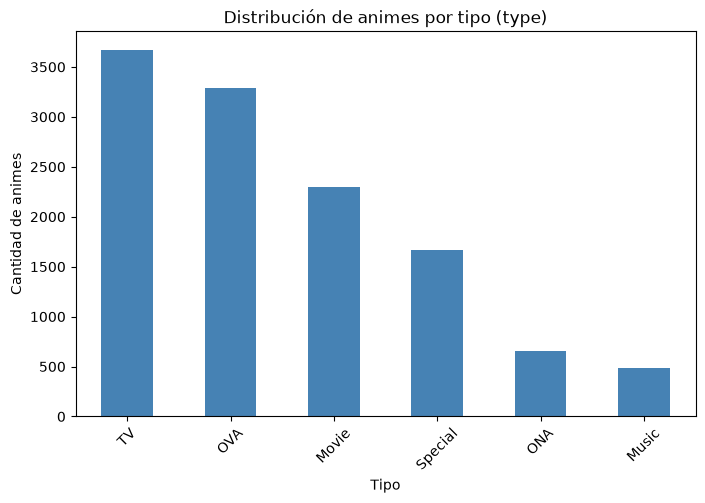

In [18]:
plt.figure(figsize=(8,5))
df['type'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribución de animes por tipo (type)')
plt.xlabel('Tipo')
plt.ylabel('Cantidad de animes')
plt.xticks(rotation=45)
plt.show()

Se nota clarísimo que TV (3,671) y OVA (3,285) son los tipos más comunes en el catálogo, seguidos de Movie (2,297), mientras que Music (488) y ONA (652) casi no tienen representación. La distribución no es para nada pareja: entre los tres primeros tipos se llevan más del 75% del catálogo.

**Recomendación (toma de decisiones):** si alguien tuviera que armar el catálogo de una plataforma, tendría sentido que el grueso de la inversión se vaya a contenido tipo **TV**, porque no solo es el más numeroso sino que además es el mejor calificado (6.90) y el más popular (43,775 members promedio), como vimos en la Fase 3. Ojo con no leer mal el gráfico: que haya muchos OVA no quiere decir que sean los que más se ven — son muchos títulos pero cada uno con poca audiencia.

**2) Gráfico de pie — proporción de animes "outlier" en popularidad**

Usamos una variable binaria que construimos nosotros con el criterio IQR del punto 11: cada anime es outlier de popularidad o no lo es.

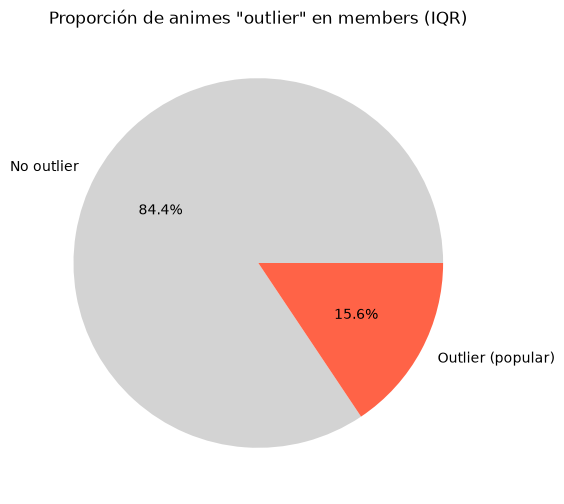

es_outlier_members
False    10180
True      1884
Name: count, dtype: int64


In [19]:
# Reutilizamos el criterio IQR del punto 11
Q1 = df['members'].quantile(0.25)
Q3 = df['members'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

df['es_outlier_members'] = df['members'] > limite_superior

conteo = df['es_outlier_members'].value_counts()
# Las etiquetas y colores salen del índice, para que no se puedan invertir
etiquetas = ['Outlier (popular)' if v else 'No outlier' for v in conteo.index]
colores = ['tomato' if v else 'lightgray' for v in conteo.index]

plt.figure(figsize=(6, 6))
plt.pie(conteo, labels=etiquetas, autopct='%1.1f%%', colors=colores)
plt.title('Proporción de animes "outlier" en members (IQR)')
plt.show()

print(conteo)

El 15.6% de los animes son outliers de popularidad, y coincide exacto con lo que habíamos calculado a mano en la Fase 2 (15.62%). En términos de negocio, esto dice que casi toda la atención de la comunidad se concentra en un grupo chiquito de animes "top", mientras que el 84.4% restante son animes de nicho que casi nadie ve.

**Recomendación (toma de decisiones):** si uno tuviera que invertir en promoción, tendría más sentido enfocarse en ese ~15% que ya tiene tracción, en vez de repartir el esfuerzo parejo entre los 12,064 títulos. Y para el catálogo, ese 84% de cola larga no hay que botarlo: es barato de licenciar y sirve para retener nichos, pero no debería ocupar la portada.

**3) Histograma — distribución de la variable numérica `rating`**

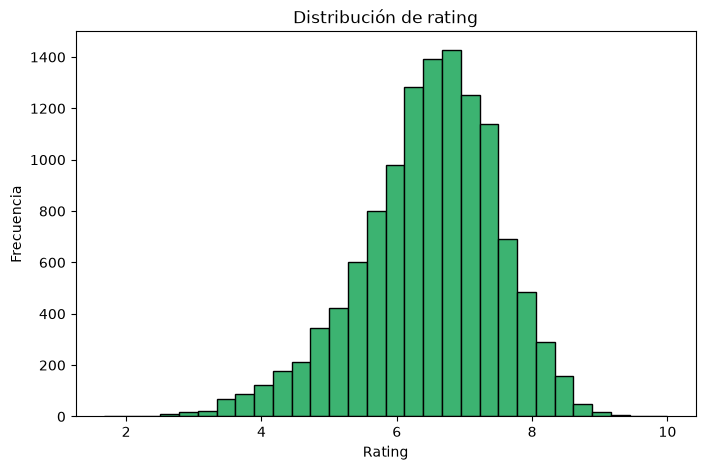

In [20]:
plt.figure(figsize=(8,5))
plt.hist(df['rating'], bins=30, color='mediumseagreen', edgecolor='black')
plt.title('Distribución de rating')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')
plt.show()

La forma es más o menos una campana, pero con una colita más larga hacia la izquierda (hacia los ratings bajos): el coeficiente de asimetría da **-0.54**, o sea **sesgo negativo**, no es simétrica. En cristiano: hay más animes "medio buenos" que animes malísimos, y la masa se concentra entre 5.5 y 8, que es justo donde vive el "anime promedio". Por debajo de 4 casi no hay nada.

**Recomendación (toma de decisiones):** como el rating está tan apretado alrededor de 6.5 (desviación de apenas 1.03), usarlo crudo para ordenar un catálogo no sirve de mucho — la diferencia entre un anime "bueno" y uno "normal" son décimas, y a un usuario eso no le dice nada. Para recomendar contenido conviene o bien combinarlo con `members`, o bien convertirlo en categorías (bajo / medio / alto) usando los cuartiles (5.88, 6.57 y 7.18), que es una señal mucho más legible para el usuario final.

**4) Scatter plot — relación entre `rating` y `members`**

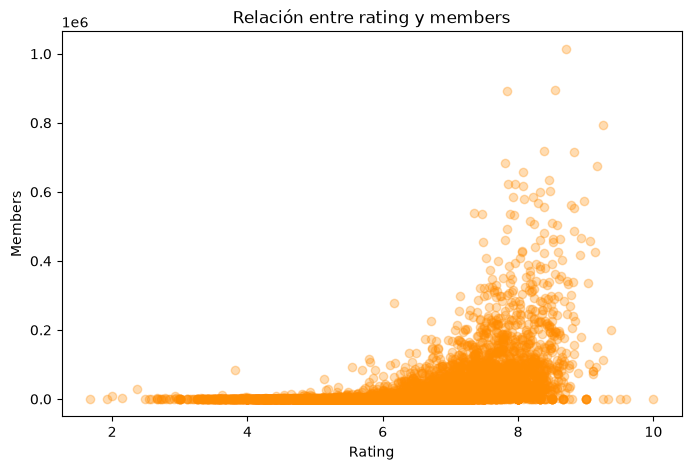

Correlación: 0.38797945850031657


In [21]:
plt.figure(figsize=(8,5))
plt.scatter(df['rating'], df['members'], alpha=0.3, color='darkorange')
plt.title('Relación entre rating y members')
plt.xlabel('Rating')
plt.ylabel('Members')
plt.show()

print("Correlación:", df['rating'].corr(df['members']))

La correlación nos dio 0.39, que es **positiva pero débil-moderada**, no fuerte. Viendo el gráfico, se nota que casi ningún anime con rating bajo tiene muchos members, pero entre los de rating alto hay de todo: algunos con pocos members y otros con muchísimos. O sea, tener buen rating parece ser casi un requisito para ser popular, pero no lo garantiza — hay otros factores de por medio (qué tan viejo es el anime, cuánto se promocionó, si salió en Netflix, etc.), y ninguno de esos está en el dataset.

**Recomendación (toma de decisiones):** con una correlación de 0.39 no se puede predecir la popularidad usando solo el rating, así que un ranking basado en una sola de las dos variables va a quedar mal. Lo accionable está en los cuadrantes: arriba a la derecha (buen rating **y** muchos members) están las apuestas seguras para portada; y arriba a la izquierda (buen rating pero pocos members) están las **joyas escondidas**, que es el grupo al que sí le rendiría una campaña de promoción, porque la calidad ya está demostrada y lo único que falta es que la gente los descubra.

**5) Boxplot — `members`**

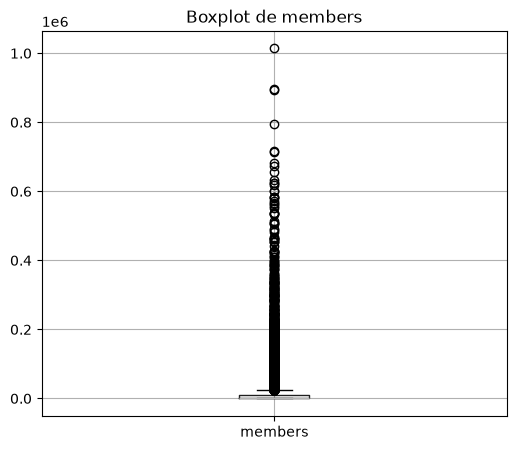

In [22]:
plt.figure(figsize=(6,5))
df.boxplot(column='members')
plt.title('Boxplot de members')
plt.show()

Se ve clarísimo lo que ya sabíamos: la caja queda pegada casi al piso (porque la mayoría de animes tienen pocos members) y hay una nube enorme de puntos por encima que son los outliers. Es exactamente lo mismo que encontramos con el criterio IQR en la Fase 2 (1,884 animes, 15.62%), solo que acá se ve de forma visual en vez de numérica. También se confirma que por debajo no hay ni un outlier, porque `members` no puede ser negativo.

**Recomendación (toma de decisiones):** antes de meter `members` en un modelo o en un gráfico hay que **transformarla** (por ejemplo con logaritmo), porque en esta escala unos pocos títulos se comen todo el espacio y aplastan al resto — el gráfico se vuelve ilegible. Y para reportarle a alguien "cómo le va al anime típico" hay que usar la **mediana (~1,540 members)**, nunca el promedio (~18,300): el promedio está inflado por Death Note y compañía y da una idea completamente equivocada del catálogo.

**6) Punto 21 — el gráfico de líneas no aplica, lo reemplazamos por un segundo boxplot**

Como anotamos en la Fase 1, este dataset **no tiene ninguna variable temporal**: no hay año de estreno, ni fecha de emisión, ni temporada. Sin eje de tiempo, un gráfico de líneas convencional no tendría ningún sentido (uniría puntos que no están ordenados por nada). Por eso aplicamos la opción alternativa que da el enunciado: un segundo boxplot comparando la variable numérica principal (`rating`) entre varias categorías (`type`).

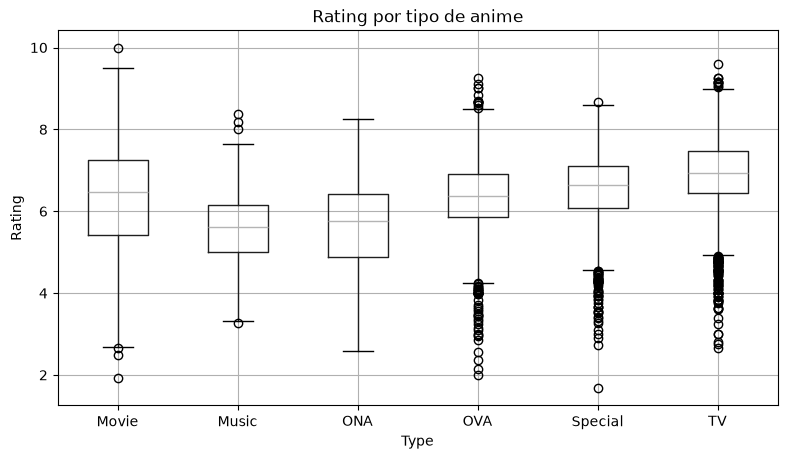

In [23]:
# df.boxplot(by=...) crea su propia figura, por eso el figsize va como argumento
df.boxplot(column='rating', by='type', figsize=(9, 5))
plt.title('Rating por tipo de anime')
plt.suptitle('')
plt.xlabel('Type')
plt.ylabel('Rating')
plt.show()

TV tiene la mediana más alta de todos los tipos (6.94), lo cual confirma otra vez lo que vimos con el groupby y con el diccionario del punto 13, y le siguen Special (6.63) y Movie (6.47). Music (5.62) y ONA (5.76) quedan claramente abajo.

Ahora, mirando el **ancho de las cajas** (que es el IQR, o sea qué tan dispersos están los ratings dentro de cada tipo) nos llevamos una sorpresa: la caja más ancha es la de **Movie** (IQR de 1.83), seguida de ONA (1.54). Las películas son el formato más impredecible en calidad — hay desde obras maestras hasta películas malísimas. En cambio **TV tiene la caja más angosta (IQR de 1.02)**, o sea que además de ser el mejor calificado es el **más consistente**: casi todas las series de TV caen entre 6.44 y 7.46.

Eso sí, TV es también el que más outliers hacia abajo tiene en números absolutos (93 series con rating anormalmente bajo), aunque en proporción el que más tiene es Special (3.3% de sus títulos). O sea que no todo lo que es TV es bueno automáticamente; en promedio le va mejor, pero hay una cola de series flojas.

**Recomendación (toma de decisiones):** si el objetivo es la satisfacción del usuario, el catálogo debería apoyarse en **TV** y **Special** (las medianas más altas) y tratar **Music** y **ONA** como contenido secundario o de relleno, no como apuesta principal. Con las películas hay que ser más selectivo que con las series: como su caja es la más ancha, el tipo "Movie" por sí solo no garantiza nada y toca revisar título por título. En general, **filtrar solo por categoría no alcanza** — la decisión de qué licenciar tiene que mirar el rating de cada anime.

## Fase 5 — Conclusiones

Para cerrar, armamos un resumen visual con las 4 gráficas que mejor explican los hallazgos principales: la distribución por tipo, la proporción de outliers de popularidad, la distribución del rating y cómo varía el rating según el tipo de anime.

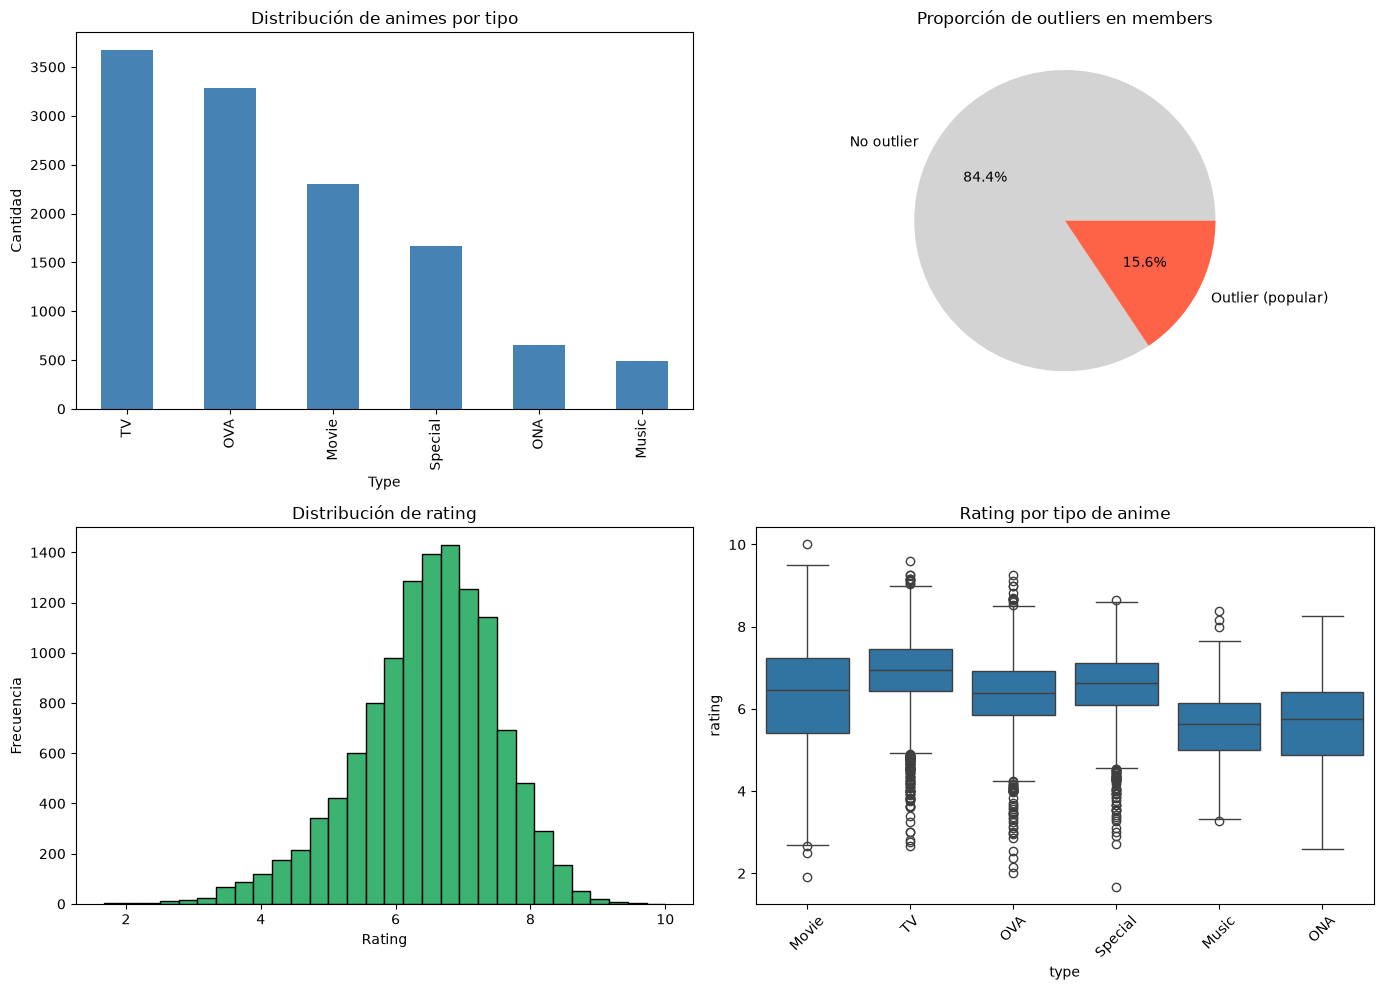

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Barras: distribución por type
df['type'].value_counts().plot(kind='bar', color='steelblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribución de animes por tipo')
axes[0, 0].set_xlabel('Type')
axes[0, 0].set_ylabel('Cantidad')

# 2. Pie: outliers en members
conteo = df['es_outlier_members'].value_counts()
etiquetas = ['Outlier (popular)' if v else 'No outlier' for v in conteo.index]
colores = ['tomato' if v else 'lightgray' for v in conteo.index]
axes[0, 1].pie(conteo, labels=etiquetas, autopct='%1.1f%%', colors=colores)
axes[0, 1].set_title('Proporción de outliers en members')

# 3. Histograma: rating
axes[1, 0].hist(df['rating'], bins=30, color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('Distribución de rating')
axes[1, 0].set_xlabel('Rating')
axes[1, 0].set_ylabel('Frecuencia')

# 4. Boxplot: rating por type
sns.boxplot(x='type', y='rating', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Rating por tipo de anime')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Conclusiones generales

**Qué aprendimos del dataset.** La mayoría de los animes del catálogo son de tipo TV y OVA, y justamente TV es el que mejor le va tanto en calificación (6.90 promedio) como en popularidad (casi 44 mil members promedio, más de 4 veces el segundo lugar). También vimos que la popularidad está repartida de forma muy desigual: solo un 15.62% de los animes concentra casi toda la atención de la comunidad, y el resto es cola larga de nicho. El rating, en cambio, se comporta mucho más "normal": una campana angosta alrededor de 6.5 con un sesgo leve hacia la izquierda (-0.54).

**Qué variables parecen más relevantes.** Nos quedamos con tres. `members` es la mejor medida de popularidad, pero hay que usarla con cuidado porque su distribución es extremadamente sesgada (media 18,071 contra mediana 1,550 en el dataset original; después de la limpieza quedan en 18,280 y 1,539) y pide una transformación logarítmica. `rating` es la medida de calidad percibida, aunque con poca varianza y sin respaldo de cuántos votos la sostienen. Y `type` resultó ser la variable categórica más informativa: separa bien tanto el rating como los members, mucho mejor de lo que esperábamos al principio. `genre` promete pero necesita trabajo previo, porque al ser multi-valor no se puede usar tal cual. `anime_id` y `name` no aportan nada como predictores: son identificadores.

**Qué limpieza fue necesaria y por qué.** Cuatro cosas. (1) `episodes` venía como texto porque tenía la palabra "Unknown"; al convertirla a numérica aparecieron 340 nulos, que imputamos con la **mediana** y no con la media, porque la columna tiene outliers extremos (hay un anime con 1,818 episodios) que inflan el promedio. (2) Los 62 nulos de `genre` los llenamos con "Unknown" en vez de borrar la fila, para no perder el rating y los members de esos animes. (3) Las 230 filas sin `type` o sin `rating` sí las eliminamos, porque inventarse la calificación de un anime sería fabricar el dato justo que queremos analizar; verificamos además que los 25 registros sin `type` eran un subconjunto de los 230 sin `rating`, y como es menos del 2% del total no afecta las conclusiones. (4) En la revisión de formato encontramos que 286 nombres traían entidades HTML sin decodificar (`Gintama&#039;`, `Tiger &amp; Bunny`), herencia del scraping original, que corregimos con `html.unescape()`; y comprobamos que partir `genre` por coma sin hacer `.strip()` duplicaba el conteo de géneros de 44 a 83. Duplicados de fila completa no había, y los 2 nombres repetidos resultaron ser adaptaciones distintas del mismo título, así que los dejamos.

**Lo que más nos sorprendió.** Que rating y members estén tan poco correlacionados (0.39). Uno asumiría que lo bueno se vuelve popular automáticamente, y resulta que no: se puede ser muy bueno sin ser masivo. El caso extremo fue un anime con rating 10.0 y apenas 13 members, que más que "la mejor obra del catálogo" es "dos personas lo vieron y les gustó". Eso deja claro que un promedio sin el número de votos detrás no es una métrica confiable.

**Preguntas abiertas para un futuro modelo de Machine Learning.**
1. ¿Se puede predecir el `rating` de un anime a partir de su `genre` y su `type`? Habría que convertir los géneros a variables dummy (one-hot) porque son multi-valor, y arrancaríamos con una regresión lineal como línea base.
2. ¿Cómo se le pone un peso al rating para que los animes con poquísimos seguidores no distorsionen el análisis? Una opción sería un promedio bayesiano ponderado por `members`, parecido a lo que usa IMDb.
3. ¿Hay géneros que estén sistemáticamente asociados a mejor recepción, o el efecto que vemos es en realidad del `type`?
4. Para predecir popularidad (`members`) casi seguro necesitamos variables que este archivo no tiene: año de estreno, estudio de animación, presupuesto. Ahí es donde entraría a jugar el otro archivo del dataset, `rating.csv`, con los 7.8 millones de calificaciones individuales, que permitiría además construir un sistema de recomendación de verdad (filtrado colaborativo) en vez de solo describir el catálogo.